In [2]:
import os
import numpy as np
import pandas as pd
import scipy as sp
import topas2numpy as tn
import matplotlib.pyplot as plt
from ipywidgets import interact
import matplotlib.colors as colors
import matplotlib.ticker as ticker

import seaborn as sns
import importlib

import sys
sys.path.append('..')
from preprocessSimulation import Preprocessor

In [6]:
folder = 'sim4'
path_dose = os.path.join(folder, 'DoseGrid.csv')
path_current_elX = os.path.join(folder, 'vCurrentElX.csv')
path_current_elY = os.path.join(folder, 'vCurrentElY.csv')
path_current_elZ = os.path.join(folder, 'vCurrentElZ.csv')

bin_x = 0.2
bin_y = 0.2
bin_z = 0.2

data_dose = Preprocessor(path_dose, 'dose', bin_x, bin_y, bin_z).data
data_current_el = Preprocessor([path_current_elX, path_current_elY, path_current_elZ], 'current', bin_x, bin_y, bin_z).data

data_dose

Calculated radial distances from 0.0 to 35.35533905932738 with center at (25.0, 25.0)
Loading data from sim4\vCurrentElX.csv...
Loading data from sim4\vCurrentElY.csv...
Loading data from sim4\vCurrentElZ.csv...
Calculated radial distances from 0.0 to 35.35533905932738 with center at (25.0, 25.0)


,x,y,z,dose,std,hist,x_cm,y_cm,z_cm,r,r_cm
0,0,0,0,5.012318e-09,1.277735e-12,10000000,0.0,0.0,0.0,35.355339,7.071068
1,0,0,1,1.719451e-09,5.437368e-13,10000000,0.0,0.0,0.2,35.355339,7.071068
2,0,0,2,2.590315e-09,6.823376e-13,10000000,0.0,0.0,0.4,35.355339,7.071068
3,0,0,3,2.288760e-09,7.237678e-13,10000000,0.0,0.0,0.6,35.355339,7.071068
4,0,0,4,6.796972e-09,1.387706e-12,10000000,0.0,0.0,0.8,35.355339,7.071068
...,...,...,...,...,...,...,...,...,...,...,...
124995,49,49,45,2.017687e-08,3.559083e-12,10000000,9.8,9.8,9.0,33.941125,6.788225
124996,49,49,46,1.018209e-08,2.684736e-12,10000000,9.8,9.8,9.2,33.941125,6.788225
124997,49,49,47,7.208254e-09,1.430103e-12,10000000,9.8,9.8,9.4,33.941125,6.788225
124998,49,49,48,2.059373e-08,3.901727e-12,10000000,9.8,9.8,9.6,33.941125,6.788225


E:\Christoph\tmp\ipykernel_29260\3465403710.py:15: UserWarning: Legend does not support handles for Axes instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([plt1, plt2], ['Dose (Gy)', 'Current (q/mm^2)'])


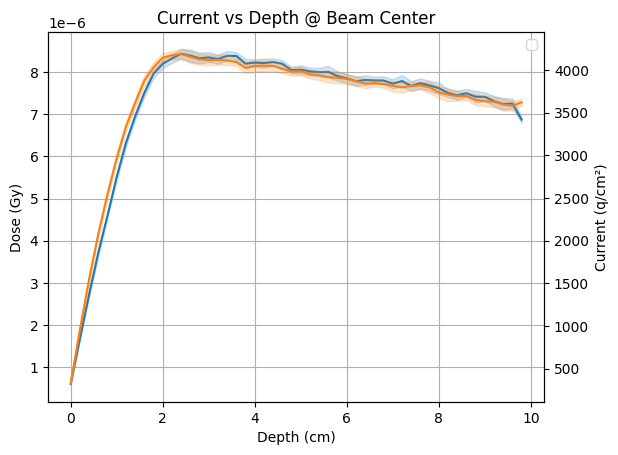

In [ ]:
center_x = int(data_dose['x_cm'].median())
center_y = int(data_dose['y_cm'].median())
filter_center = (data_dose['x_cm'] > center_x - 0.5) & (data_dose['x_cm'] < center_x + 0.5) & (data_dose['y_cm'] > center_y - 0.5) & (data_dose['y_cm'] < center_y + 0.5)
data_current_el_filtered = data_current_el[filter_center]
data_dose_filtered = data_dose[filter_center]

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

plt1 = sns.lineplot(data=data_dose_filtered, x='z_cm', y='dose', ax=ax1, color="tab:blue")
plt2 = sns.lineplot(data=data_current_el_filtered, x='z_cm', y='jz_cm_abs', ax=ax2, color="tab:orange")

plt.legend([plt1, plt2], ['Dose (Gy)', 'Current (q/cm²)'])
ax1.set_xlabel('Depth (cm)')
ax1.set_ylabel('Dose (Gy)')
ax2.set_ylabel('Current (q/cm²)')
plt.title('Current vs Depth @ Beam Center')
ax1.grid()

Text(602.5923756705452, 0.5, 'Y Position (cm)')

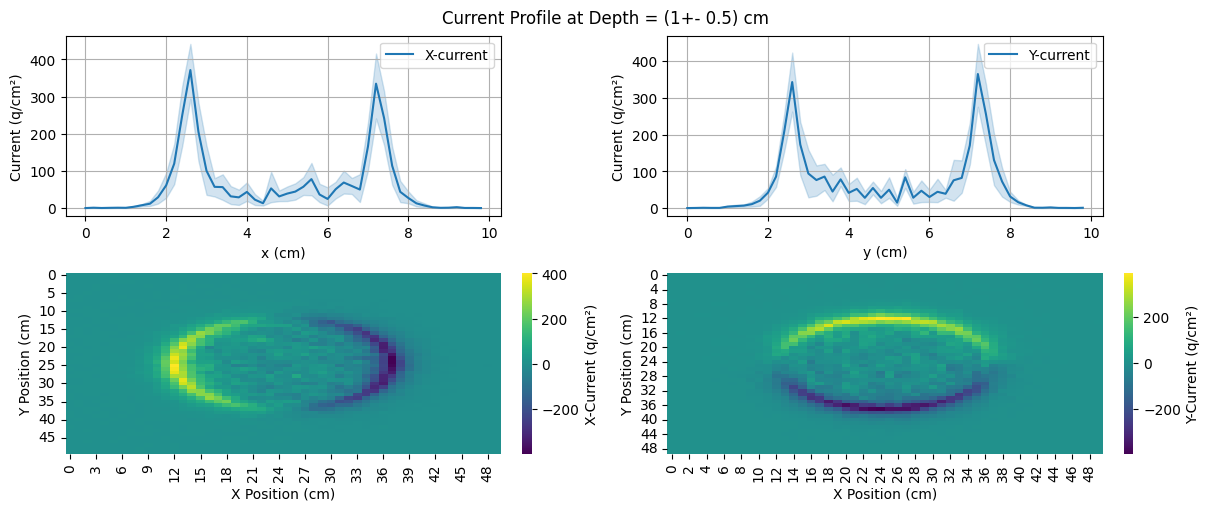

In [12]:
depth = 1
filter_depth = (data_current_el['z_cm'] > depth-0.5) & (data_current_el['z_cm'] < depth+0.5)
data_current_el_filtered = data_current_el[filter_depth]
data_current_el_filtered_x = data_current_el_filtered[(data_current_el_filtered['y_cm'] == int(data_current_el_filtered['y_cm'].median()))]
data_current_el_filtered_y = data_current_el_filtered[(data_current_el_filtered['x_cm'] == int(data_current_el_filtered['x_cm'].median()))]

pivot_data_x = data_current_el_filtered.pivot_table(index='y_cm', columns='x_cm', values='jx_cm')
pivot_data_y = data_current_el_filtered.pivot_table(index='y_cm', columns='x_cm', values='jy_cm')

fig, ax = plt.subplots(2, 2, figsize=(12, 5), constrained_layout=True)
plt.suptitle(f'Current Profile at Depth = ({depth}+- 0.5) cm')

sns.lineplot(data=data_current_el_filtered_x, x='x_cm', y='jx_cm_abs', ax=ax[0, 0], label='X-current')
ax[0, 0].set_xlabel('x (cm)')
ax[0, 0].set_ylabel('Current (q/cm²)')
ax[0, 0].grid()

sns.heatmap(pivot_data_x, cmap='viridis', ax=ax[1, 0], cbar_kws={'label': 'X-Current (q/cm²)'})
ax[1, 0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.d'))
ax[1, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.d'))
ax[1, 0].set_xlabel(r'X Position (cm)')
ax[1, 0].set_ylabel(r'Y Position (cm)')

sns.lineplot(data=data_current_el_filtered_y, x='y_cm', y='jy_cm_abs', ax=ax[0, 1], label='Y-current')
ax[0, 1].set_xlabel('y (cm)')
ax[0, 1].set_ylabel('Current (q/cm²)')
ax[0, 1].grid()

sns.heatmap(pivot_data_y, cmap='viridis', ax=ax[1, 1], cbar_kws={'label': 'Y-Current (q/cm²)'})
ax[1, 1].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.d'))
ax[1, 1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.d'))
ax[1, 1].set_xlabel(r'X Position (cm)')
ax[1, 1].set_ylabel(r'Y Position (cm)')

Text(277.65081805555565, 0.5, 'Y Position (cm)')

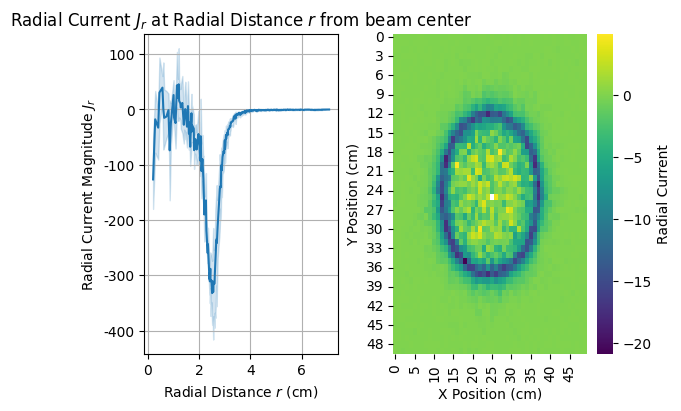

In [9]:
pivot_data_r = data_current_el_filtered.pivot_table(index='y_cm', columns='x_cm', values='jr')

fig, ax = plt.subplots(1,2, figsize=(6, 4), constrained_layout=True)

sns.lineplot(data=data_current_el_filtered, x='r_cm', y='jr_cm', ax=ax[0])
ax[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.d'))
ax[0].grid()
ax[0].set_title(r'Radial Current $J_r$ at Radial Distance $r$ from beam center')
ax[0].set_xlabel(r'Radial Distance $r$ (cm)')
ax[0].set_ylabel(r'Radial Current Magnitude $J_r$')

sns.heatmap(pivot_data_r, cmap='viridis', ax=ax[1], cbar_kws={'label': 'Radial Current'})
ax[1].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.d'))
ax[1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.d'))
ax[1].set_xlabel(r'X Position (cm)')
ax[1].set_ylabel(r'Y Position (cm)')